In [131]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

In [132]:
df = pd.read_csv("../data/BostonHousing.csv")

In [133]:
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


The target variable of the Boston housing dataset is medv. The following are the data descriptions:

* CRIM     per capita crime rate by town
* ZN       proportion of residential land zoned for lots over 25,000 sq.ft.
* INDUS    proportion of non-retail business acres per town
* CHAS     Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
* NOX      nitric oxides concentration (parts per 10 million)
* RM       average number of rooms per dwelling
* AGE      proportion of owner-occupied units built prior to 1940
* DIS      weighted distances to five Boston employment centres
* RAD      index of accessibility to radial highways
* TAX      full-value property-tax rate per $10,000
* PTRATIO  pupil-teacher ratio by town
* B        1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town
* LSTAT    % lower status of the population
* MEDV     Median value of owner-occupied homes in $1000's


In [134]:
df.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [135]:
TARGET = "medv"
drop_cols = ["medv", "b"]
X = df.drop(drop_cols, axis=1)
y = df[TARGET]

# EDA

Text(0.5, 1.0, 'Distribution of target variable (median value homes)')

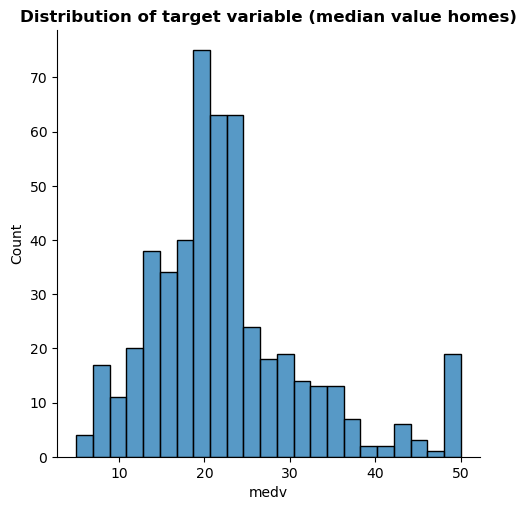

In [136]:
sns.displot(df.medv)
plt.title("Distribution of target variable (median value homes)", weight = 'bold')

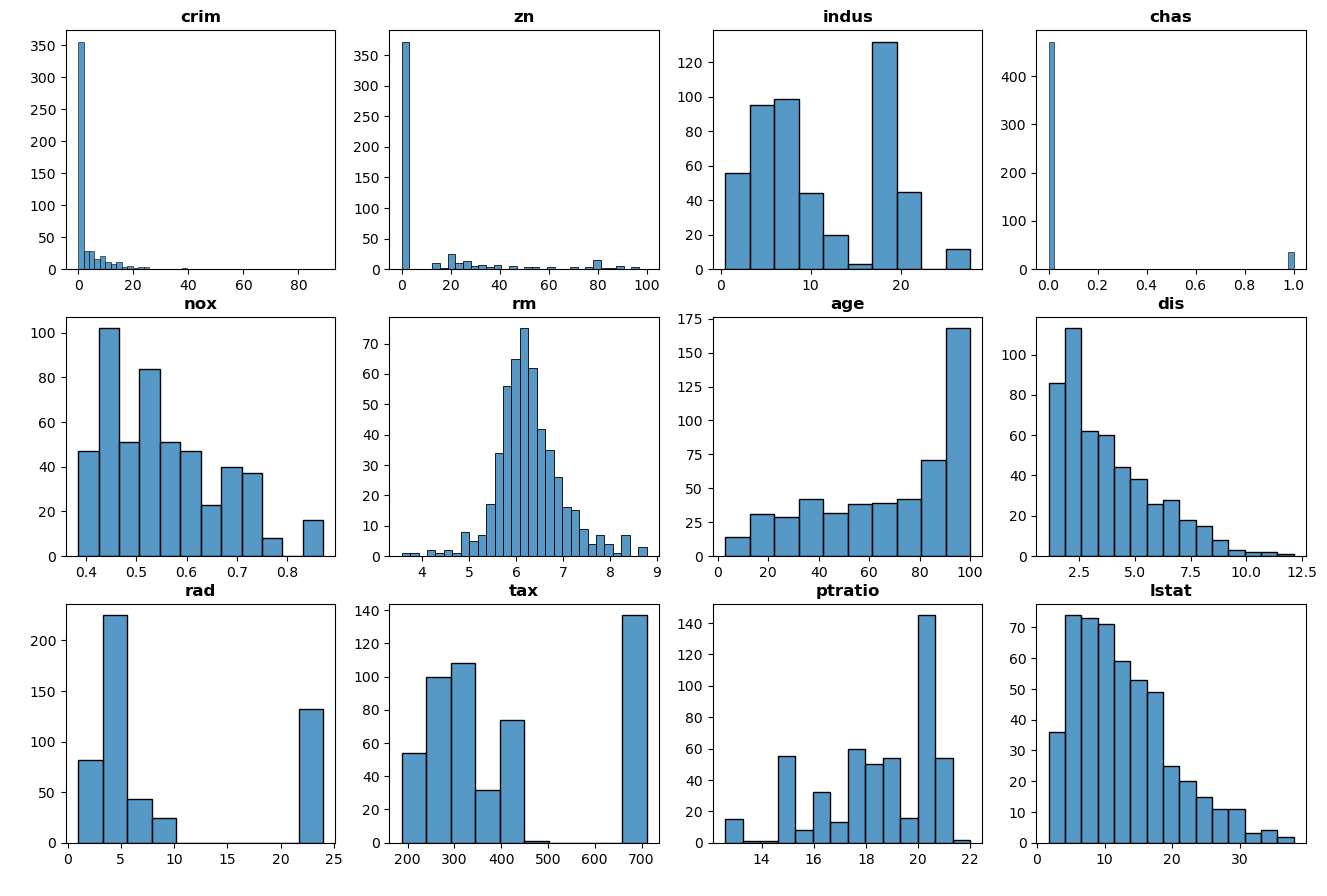

In [137]:
plt.figure(figsize= (16,18))
for i,col in enumerate(X.columns):
    plt.subplot(5,4, i+1)
    sns.histplot(df[col])
    plt.title(col, weight = 'bold')
    plt.ylabel(" ")
    plt.xlabel(" ")

**Notes:** The feature *chas* is actually binary.

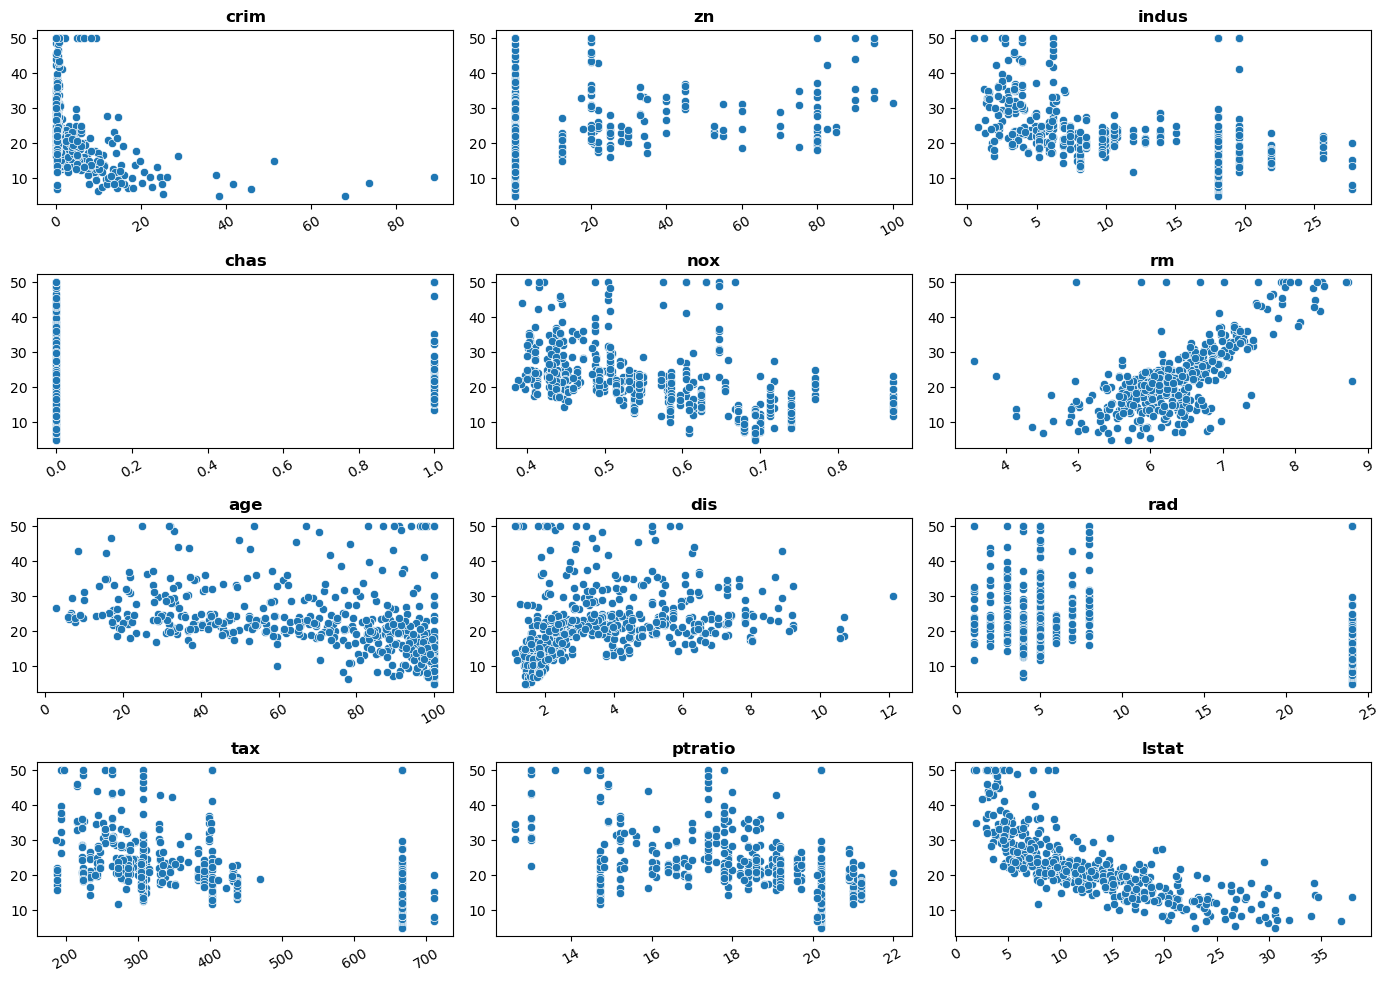

In [138]:
plt.figure(figsize=(14, 12))

# Iterate over columns and plot
for i, col in enumerate(X.columns, 1):
    plt.subplot(5, 3, i)  # Create subplots dynamically
    #sns.histplot(data=df, x=col, kde=True, bins=10, color='skyblue') 
    sns.scatterplot(data=df, x=col, y="medv")# Add histograms
    plt.title(col, weight='bold', fontsize=12)  # Adjust font size for better readability
    plt.ylabel("")  # Remove redundant y-axis label
    plt.xlabel("")  # Remove redundant x-axis label
    plt.xticks(rotation=30, fontsize=10)  # Rotate x-axis labels for better visibility
    plt.yticks(fontsize=10)  # Adjust y-axis ticks size

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

In [139]:
BIN_FEAT = ["chas"]
NUM_FEAT = [col for col in X.columns if col not in BIN_FEAT]

<Axes: >

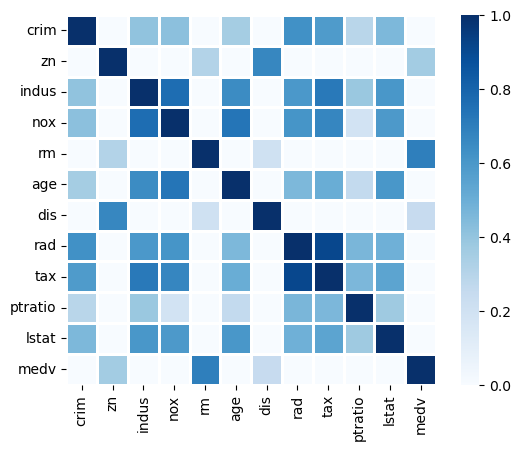

In [140]:
corr = df[NUM_FEAT + [TARGET]].corr()
sns.heatmap(corr, vmin=0, vmax=1, linewidths=2, square=True, cmap='Blues')

# Try initial models

## Linear regression

In [141]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize only the numeric features with a ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), NUM_FEAT)
    ],
    remainder="passthrough"
)

X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

In [142]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_test_scaled)
print("RMSE: ", root_mean_squared_error(y_test, y_pred))

RMSE:  4.772599769922683


## Random forest

In [143]:
rf_model = RandomForestRegressor(
    n_estimators=3,
    random_state=42
)

rf_model.fit(X_train_scaled, y_train)

y_pred = rf_model.predict(X_test_scaled)

print("RMSE: ", root_mean_squared_error(y_test, y_pred))

RMSE:  4.1642502797210526


## Support vector machine

In [144]:
svr_model = SVR(C=1.0, epsilon=0.2)

svr_model.fit(X_train_scaled, y_train)
y_pred = svr_model.predict(X_test_scaled)

print(f"Root Mean Squared Error is: {root_mean_squared_error(y_test, y_pred)}")

Root Mean Squared Error is: 4.9608336616821775


# Fine-tuned models

## Linear regression without colinear features

<Axes: >

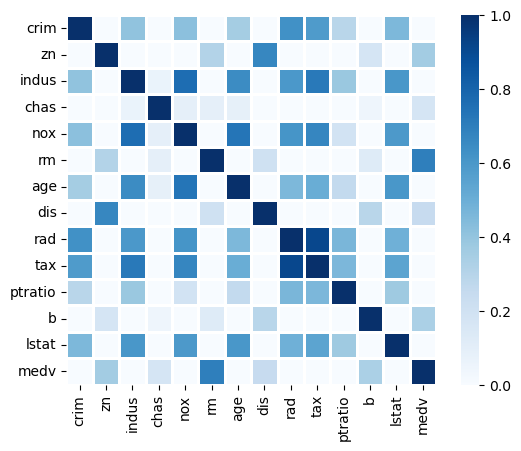

In [145]:
corr = df.corr()
sns.heatmap(corr, vmin=0, vmax=1, linewidths=2, square=True, cmap='Blues')

In [146]:
# Identify highly correlated features (collinearity)
correlation_threshold = 0.7
high_corr_pairs = []

# Get upper triangle of correlation matrix
upper = corr.where(np.triu(np.ones_like(corr), k=1).astype(bool))

# Find pairs with correlation above threshold
for col in upper.columns:
    for idx in upper.index:
        if abs(upper.loc[idx, col]) > correlation_threshold:
            high_corr_pairs.append((idx, col, upper.loc[idx, col]))

print("Highly correlated feature pairs (|correlation| > 0.8):")
for pair in high_corr_pairs:
    print(f"{pair[0]} - {pair[1]}: {pair[2]:.3f}")

# Alternative: Get correlation matrix for features only (excluding target)
feature_corr = df[NUM_FEAT].corr()
upper_features = feature_corr.where(np.triu(np.ones_like(feature_corr), k=1).astype(bool))

# Find most correlated feature pairs
most_corr = upper_features.stack().sort_values(ascending=False)
print("\nTop 5 most correlated feature pairs:")
print(most_corr.head(5))

Highly correlated feature pairs (|correlation| > 0.8):
indus - nox: 0.764
nox - age: 0.731
indus - dis: -0.708
nox - dis: -0.769
age - dis: -0.748
indus - tax: 0.721
rad - tax: 0.910
lstat - medv: -0.738

Top 5 most correlated feature pairs:
rad    tax    0.910228
indus  nox    0.763651
nox    age    0.731470
indus  tax    0.720760
nox    tax    0.668023
dtype: float64


In [147]:
# Remove highly correlated features to reduce multicollinearity
features_to_remove = ["rad", "nox", "indus"]
NUM_FEAT_WITHOUT_COLLIN = [feat for feat in NUM_FEAT if feat not in features_to_remove]

print("Updated NUM_FEAT after removing collinear features:")
print(NUM_FEAT_WITHOUT_COLLIN)

Updated NUM_FEAT after removing collinear features:
['crim', 'zn', 'rm', 'age', 'dis', 'tax', 'ptratio', 'lstat']


In [148]:
TARGET = "medv"
X = df[NUM_FEAT_WITHOUT_COLLIN + BIN_FEAT]
y = df[TARGET]

In [149]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize only the numeric features with a ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), NUM_FEAT_WITHOUT_COLLIN)
    ],
    remainder="passthrough"
)

X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

In [150]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_test_scaled)
print("RMSE: ", root_mean_squared_error(y_test, y_pred))

RMSE:  5.0970478723038894


## Random forest with fine-tuning